# 260827 Linear Regression 2
[machine learning chapter02-2, 03-1]

---

## 1. Today's Goal

- 오늘 배운 내용 복습

---

## 2. Key Concepts

### [자주 헷갈리는 개념]

선형회귀
- 원인과 결과 사이의 규칙 나타내는 직선을 그어 미래를 예측하는 머신러닝 기법
- "regressing towards the mean"
- predicting the "continuous" numerical value such as temperature, money ...


$$
\hat{y} = wx + b
$$


- $\hat{y}$: 모델 예측값
- $w$: 가중치(기울기)
- $x$: feature(입력값), independent variable, input
- $y$: label(실제값), dependent variable, output
- $b$: 편향(bias), 절편, 기본값

How the LR works
- make prediction
- compare prediction with actual value
- calculate the error
- adjust the parameters to reduce the error
- repeat many times

Gradient Descent/optimization = how the model learns by adjusting parameters(weight and bias)
- changing w changes the steepness
- changing b moves the line up/down

the LR formular can be extended like...
- y = w1x1 + w2x2 + w3x3 + ... + b

모델 파라미터
- 모델이 스스로 학습하고 결정하는 값
- $w$, $b$

하이퍼파라미터
- 엔지니어가 학습 시작 전 미리 세팅하는 값
- Learning Rate(alpha), Epochs(학습 횟수) ...

표준편차: 데이터간 표준 거리, 떨어진 정도. 분산에 루트 씌워서 제곱에서 되돌린 값

표준점수(Z-Score): 데이터가 평균으로부터 표준편차의 몇 배만큼 떨어져 있는지






### 경사하강법 Gradient Descent

경사하강법:
- 인공지능이 정답을 맞추기 위해 오차를 가장 줄일 수 있는 최적의 상태를 찾아가는 과정 

가중치 업데이트 공식 - 경사하강법의 움직임 공식
$$
w_{\text{new}}
=
w_{\text{old}}
-
\eta \frac{\partial J}{\partial w}
$$

- $w_{\text{old}}$: 기존 가중치
- $w_{\text{new}}$: 업데이트된 가중치
- $\eta$: 학습률(Learning Rate): 가중치를 얼마나 크게 업데이트 할지 결정
- $J$: Loss 함수, 모델 성능 나쁠수록 값이 커짐 -> $J$를 최소로 만들어야 함
- $\frac{\partial J}{\partial w}$: 가중치 $w$에 대한 Loss의 기울기

Loss가 감소하는 방향으로 가중치를 조정한다.



---
$\eta$ 학습률(보폭) 잘못 설정:
- Overshooting: 보폭이 너무 클 때
- Undershooting: 보폭이 너무 작을 때
- Convergence: 적절한 보폭

---

### 다형 회귀

$$
\hat{y}
=

w_1x^1
+
w_2x^2
+
w_3x^3
+
b
$$


---

## Feature Scaling
- 모델 예측 시 여러 feature 사용 가능
- 그러나 여러 features는 다양한 숫자 단위를 가질 수 있음
- 상대적으로 큰 숫자 단위를 가진 feature는 가중치 업데이트나 거리 계산에 다른 feature보다 더 큰 영향을 줌
- 따라서 각 feature의 단위를 통일하는 scaling이 필요함
### Min-Max Scaling

- 각 값을 최소값, 최대값 기준으로 $0 \sim 1$ 사이로 압축
- 큰 이상치가 있을 경우, 다른 값들이 한쪽에 몰릴 수 있는 위험

$$
x_{\text{new}} =
\frac{x - x_{\min}}
{x_{\max} - x_{\min}}
$$

### Z-score Standardization (StandardScaler)

- 평균을 $0$, 표준편차를 $1$로 조정하여 상대적 크기로 수치를 통일화
- 각 값이 평균, 표준편차로부터 얼마나 떨어져 있는지를 나타냄
- '-2'일 경우 평균에서 -2만큼 떨어져 있는 값을 의미
- 분산을 작게 만들어줌
- 학습할때 경중이 훨씬 더 잘 반영됨

$$
x_{\text{new}} =
\frac{x - \mu}{\sigma}
$$

- $\mu$: 평균
- $\sigma$: 표준편차

---
### 데이터 분할
| 특성 1~50 | 특성 2~50 | 특성 3~50 |
|---|---|---|
- 과적합 문제 해결 방법 (분할 + 섞기)
- Train Set 60% - Validation Set 20% - Test Set 20% 으로 데이터를 분할
- `train-test-split` 함수의 하이퍼파라미터 사용
- 

---
### 특성 공학 Feature Engineering
- 특성을 조합하여 새로운 특성을 추가하는 전처리 기법
- 특성의 개수가 너무 많으면 과적합
    -> 적절히 늘리기
    -> 특성의 영향력을 줄이는 '규제 모델' 필요
- `PolynomialFeatures`

---
### 규제 모델

Ridge Regression 'L2 규제': 
가중치의 **제곱**에 패널티
$$
Loss_{\text{total}}
=
MSE
+
\lambda \sum_{j=1}^{p} w_j^2
$$

- 가중치 영향력 클수록 Loss값 크게 올림
- 가중치를 0으로 만들지는 않음
- 가장 많이 쓰는 규제

Lasso Regression 'L1 규제': 
가중치의 **절댓값**에 패널티(Loss값을 올림)

$$
Loss_{\text{total}}
=
MSE
+
\lambda \sum_{j=1}^{p} |w_j|
$$

- 중요도가 낮은 feature 가중치 0으로 만듬
- 가중치가 0인 feature = 예측에 사용되지 않음
- feature 선택 효과

| 구분 | Min-Max / Z-score | Ridge / Lasso |
|---|---|---|
| 정확한 구분 | **Feature Scaling** (전처리) | **Regularization** (규제) |
| 대상 | 입력 feature 값 \(X\) | 모델 가중치 \(w\) |
| 목적 | 단위·범위를 맞춤 | 과적합 방지 |
| 적용 시점 | 학습 전 | Loss 함수 안에서 학습 중 |
| 가중치 변화 | 직접 조정하지 않음 | 큰 가중치에 패널티 |
| 예시 | 면적 \(10\sim1000\), 학군 \(1\sim5\)의 스케일 통일 | 불필요하게 큰 \(w\)를 줄임 |

---
### 규제 방법

규제 강도 (alpha) 사용
- by log `np.logspace(~부터, ~까지, ~단계)`

---
### 다중공선성 multicollinearity
원인 변수끼리의 지나친 상관관계 -> 독립적 기여도 판단 어려운 중복 간섭 현상



---

## 3. Practice 실습 코드

In [2]:
# chapter02-2 문제1
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("usa_housing.csv")

df = df[df['Bedrooms'] > 3]

X_crime = df[['CrimeRate']]
y_price = df['Price']

X_train_tmp, X_test, y_train_tmp, y_test = train_test_split(
    X_crime, y_price, test_size=0.2, random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_tmp, y_train_tmp, test_size=0.25, random_state=42
)

print("전체 데이터 개수:", X_crime.shape) 
print("Train Set:", X_train.shape)
print("Validation Set", X_valid.shape)
print("Test Set:", X_test.shape)


전체 데이터 개수: (123, 1)
Train Set: (73, 1)
Validation Set (25, 1)
Test Set: (25, 1)


In [3]:
# chapter02-2 문제2
from sklearn.preprocessing import StandardScaler # scaled된 값은 features의 값만 조정하고, 행과 열 자체는 바꾸지 않음 -> .shape를 통해 스케일링 완료한 X의 크기를 확인 가능

# 입력 데이터용 스케일러
ss_X = StandardScaler()
X_train_scaled = ss_X.fit_transform(X_train).flatten() # flatten() -> 1차원 데이터로 변환
X_valid_scaled = ss_X.transform(X_valid).flatten()
X_test_scaled = ss_X.transform(X_test).flatten()

# 타깃 데이터용 스케일러
ss_y = StandardScaler()
y_train_scaled = ss_y.fit_transform((y_train.values).reshape(-1, 1)) # 1차원 데이터(Series)는 reshape(-1, 1) -> 2차원 데이터로 변경
y_valid_scaled = ss_y.transform((y_valid.values).reshape(-1, 1))
y_test_scaled = ss_y.transform((y_test.values).reshape(-1, 1))

# 변환된 데이터의 첫 번째 값 출력
print(X_train_scaled[0])
print(X_valid_scaled[0])
print(X_test_scaled[0])

print(y_train_scaled[0])
print(y_valid_scaled[0])
print(y_test_scaled[0])

# 변환된 데이터의 전체 크기 출력
print(X_train_scaled.shape)
print(X_valid_scaled.shape)
print(X_test_scaled.shape)

print(y_train_scaled.shape)
print(y_valid_scaled.shape)
print(y_test_scaled.shape)

1.01157709790812
-0.4435138287783959
1.4346285844371707
[-1.079365]
[1.76294714]
[-0.25767126]
(73,)
(25,)
(25,)
(73, 1)
(25, 1)
(25, 1)


In [4]:
# chapter02-2 문제3
weight = 0.0
bias = 0.0
learning_rate = 0.05
epoch = 150

train_losses = []
valid_losses = []

print("weight:", weight)
print("bias:", bias)
print("learning_rate:", learning_rate)
print("epoch:", epoch)
print("train_losses:", train_losses)
print("valid_losses:", valid_losses)

weight: 0.0
bias: 0.0
learning_rate: 0.05
epoch: 150
train_losses: []
valid_losses: []


In [5]:
# chapter3-1 문제 1
import pandas as pd
from sklearn.linear_model import Ridge

df = pd.read_csv("student-por.csv")
df.head()
df.keys()

X = df[['failures', 'goout', 'health']]
y = df['G3']

model = Ridge(alpha=0) # Ridge, alpha parameter set as 0

model.fit(X, y) # 학습
print("가중치 (Weights):", model.coef_)
print("절편 (Bias):", model.intercept_)

가중치 (Weights): [-2.10765672 -0.19660247 -0.19256291]
절편 (Bias): 13.680757699345353


In [ ]:
# chapter3-1 문제 2

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# PolynomialFeatures:
# 기존 특성을 제곱항, 특성 간 곱셈항 등으로 확장하는 특성 공학 도구
poly = PolynomialFeatures(
    degree=2,          # 2차항까지 생성
    include_bias=False # 모든 값이 1인 bias(절편용) 열은 추가하지 않음
)

# X의 기존 특성을 기반으로 다항식 특성을 생성
# 예: x1, x2 → x1, x2, x1², x1*x2, x2²
X_poly = poly.fit_transform(X)

# 확장된 각 특성의 이름을 가져옴
# X.columns를 전달했기 때문에 기존 컬럼명을 기반으로 이름 생성
feature_names = poly.get_feature_names_out(X.columns)

# 특성 공학 후 데이터의 행과 열 개수 출력
# 행 개수는 그대로, 열 개수는 다항식 특성 추가로 증가
print("특성 공학이 완료된 데이터 형태:", X_poly.shape)

# 생성된 모든 특성 이름 출력
print("확장된 특성 이름:", feature_names)


# StandardScaler:
# 각 특성을 평균 0, 표준편차 1의 표준점수(Z-score) 형태로 변환
scaler = StandardScaler()

# 다항식으로 확장된 X_poly를 표준화
# 서로 특성의 단위나 값의 범위가 달라도 비슷한 기준으로 맞춰줌
X_scaled = scaler.fit_transform(X_poly)

# 표준화된 배열의 첫 번째~다섯 번째 행 출력
print(X_scaled[:5])

특성 공학이 완료된 데이터 형태: (649, 9)
확장된 특성 이름: ['failures' 'goout' 'health' 'failures^2' 'failures goout'
 'failures health' 'goout^2' 'goout health' 'health^2']
[[-0.37430512  0.69378496 -0.3710422  -0.27717038 -0.3424015  -0.3446603
   0.58782199  0.11749022 -0.59976447]
 [-0.37430512 -0.15738033 -0.3710422  -0.27717038 -0.3424015  -0.3446603
  -0.33144662 -0.34370626 -0.59976447]
 [-0.37430512 -1.00854562 -0.3710422  -0.27717038 -0.3424015  -0.3446603
  -0.98806706 -0.80490273 -0.59976447]
 [-0.37430512 -1.00854562  1.01290255 -0.27717038 -0.3424015  -0.3446603
  -0.98806706 -0.1899741   1.1159254 ]
 [-0.37430512 -1.00854562  1.01290255 -0.27717038 -0.3424015  -0.3446603
  -0.98806706 -0.1899741   1.1159254 ]]


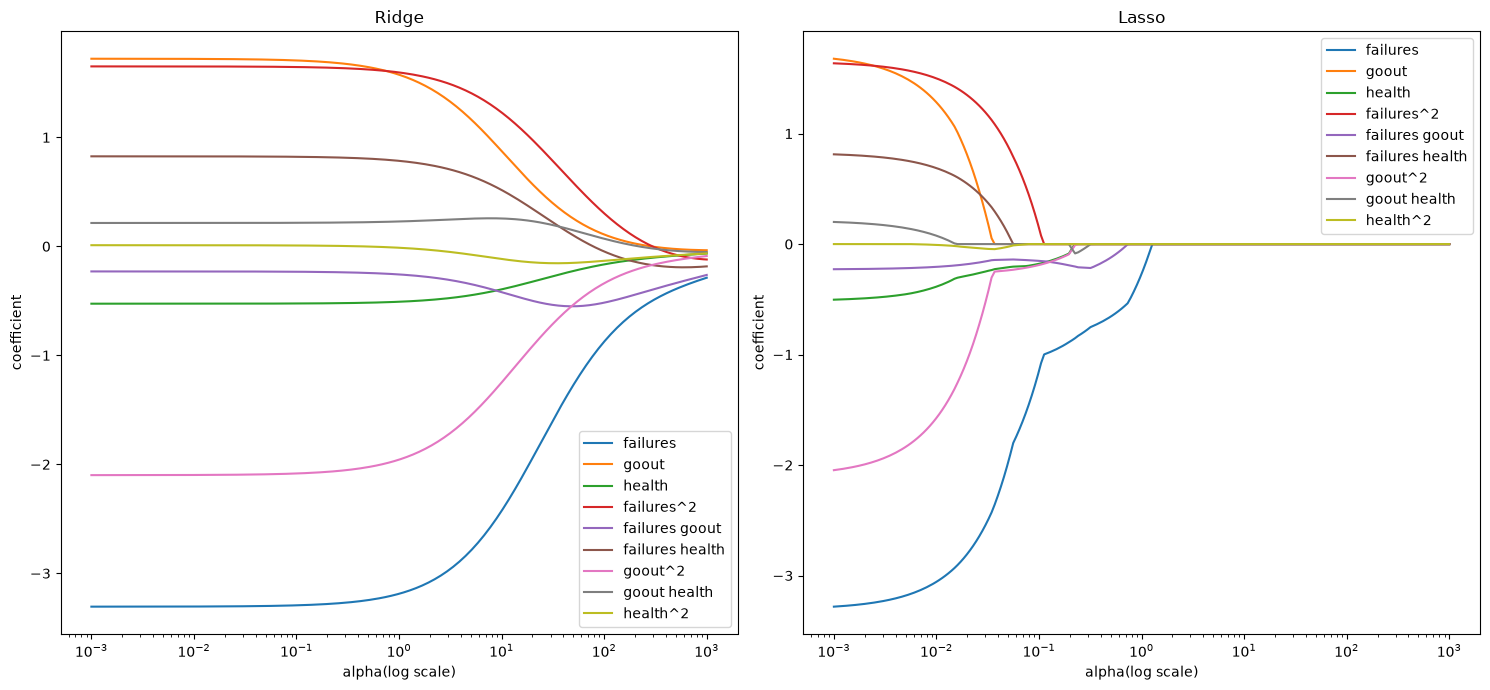

In [ ]:
#chapter3-1 문제 3
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.linear_model import Lasso

# Ridge, Lasso 회귀 계수(가중치) 담을 빈 리스트 생성
ridge_coefs = []
lasso_coefs = [] 

# logspace 생성
alphas = np.logspace(-3, 3, 200)

# alphas 순회, Ridge, Lasso 모델 생성,  X_scaled 사용
for a in alphas:
    # Ridge
    ridge = Ridge(alpha=a)
    ridge.fit(X_scaled, y)
    ridge_coefs.append(ridge.coef_) # 가중치 담기

    # Lasso
    lasso = Lasso(alpha=a, max_iter=20000, tol=1e-4)
    lasso.fit(X_scaled, y)
    lasso_coefs.append(lasso.coef_) # 가중치 담기

# numpy 배열로 변환
ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

# 1행 2열 크기의 그래프 영역 만들기
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# 왼쪽 Ridge 그래프 그리기 + x축 로그 스케일 적용
for i in range(X_scaled.shape[1]): # X_scaled Column을 돌기
    axes[0].plot(alphas, ridge_coefs[:, i], label=feature_names[i])
    axes[0].set_title('Ridge')
    axes[0].set_xscale('log')
    axes[0].set_xlabel('alpha(log scale)')
    axes[0].set_ylabel('coefficient')
    axes[0].legend()

# 오른쪽 Lasso 그래프 그리기 + y축 로그 스케일 적용
for i in range(X_scaled.shape[1]):
    axes[1].plot(alphas, lasso_coefs[:, i], label=feature_names[i])
    axes[1].set_title('Lasso')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('alpha(log scale)')
    axes[1].set_ylabel('coefficient')
    axes[1].legend()

# 그래프가 겹치지 않도록 자동으로 여백 조정
plt.tight_layout()
plt.show()




--- 
## 4. Daily Quest

> 1. 머신러닝에서 데이터를 Train, Valid, Test 세트로 나누어 학습시키는 가장 큰 이유는 무엇인가요?

답:

> 2. 집값처럼 원본 숫자가 너무 커서 인공지능 학습 시 보폭이 꼬여 최적점을 훌쩍 지나쳐버리는 현상을 무엇이라고 하나요?

답: 

> 3. train_test_split 함수에서 random_state=42로 값을 고정하는 이유로 가장 적절한 것은 무엇인가요?
답: 

> 4. 릿지(Ridge) 회귀와 라쏘(Lasso) 회귀의 차이점을 가장 정확하게 설명한 것은 무엇인가요?

답:

해설:숫자형 데이터 결측치 -> mean값으로 fill, 문자/범주형 데이터 -> 최빈값(mode)로 대체. (문자는 평균이 없으니)

> 5. 독립 변수들끼리 지나치게 밀접한 상관관계를 가져 각 변수의 독립적인 기여도를 파악하기 어렵게 만드는 현상을 무엇이라고 하나요?

답: 다중공선성

해설: 다중공선성은 변수 간 정보 중복으로 가중치 계수가 불안정해지고 모델의 해석력과 신뢰도가 떨어지는 현상입니다. VIF 수치가 10 이상이면 심각한 다중공선성으로 진단하여 변수 제거, 통합, 규제 모델 적용 등의 대응이 필요합니다.

--- 
## 5. Reflection

- 공부하는데 안풀려서 머리아프고 화나는 건 오랜만이었다.
- linear regression flow 이해 안감.. 배운내용 자체가 연결이 안된다
- 